Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
df = pd.read_csv("employee_turnover.csv")

First 5 Rows

In [ ]:
df.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

Check Missing Values

In [ ]:
df.isnull().sum()

,0
Job_Satisfaction,0
Performance_Rating,0
Years_At_Company,0
Work_Life_Balance,0
Distance_From_Home,0
Monthly_Income,0
Education_Level,0
Age,0
Num_Companies_Worked,0
Employee_Role,0


Define Features and Target

Target column:

Employee_Turnover

In [ ]:
X = df.drop("Employee_Turnover", axis=1)

y = df["Employee_Turnover"]

Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Baseline Logistic Regression
Formula

P(Y=1)=1/(1+e
^−z)
	​


In [10]:
baseline_model = LogisticRegression()

baseline_model.fit(X_train, y_train)

LogisticRegression()

Prediction

In [11]:
y_pred_baseline = baseline_model.predict(X_test)

Evaluate Baseline Model

In [12]:
print("Baseline Model Accuracy:")

print(accuracy_score(y_test, y_pred_baseline))

Baseline Model Accuracy:
0.8629629629629629


Confusion Matrix

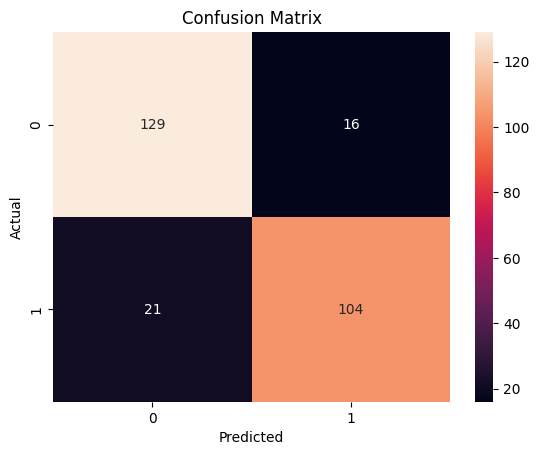

In [13]:
cm = confusion_matrix(y_test, y_pred_baseline)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Classification Report

In [14]:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87       145
           1       0.87      0.83      0.85       125

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270



L1 Regularization Model
Formula

Loss+λ∑∣wi∣

In [15]:
l1_model = LogisticRegression(
    penalty='l1',
    solver='liblinear'
)

l1_model.fit(X_train, y_train)

LogisticRegression(penalty='l1', solver='liblinear')

L1 Prediction

In [16]:
y_pred_l1 = l1_model.predict(X_test)

L1 Accuracy

In [17]:
print("L1 Accuracy:")

print(accuracy_score(y_test, y_pred_l1))

L1 Accuracy:
0.8629629629629629


L2 Regularization Model
Formula

Loss+λ∑wi^2
	​


In [18]:
l2_model = LogisticRegression(
    penalty='l2'
)

l2_model.fit(X_train, y_train)

LogisticRegression()

L2 Prediction

In [19]:
y_pred_l2 = l2_model.predict(X_test)

L2 Accuracy

In [20]:
print("L2 Accuracy:")

print(accuracy_score(y_test, y_pred_l2))

L2 Accuracy:
0.8629629629629629


Compare All Models

In [21]:
baseline_acc = accuracy_score(y_test, y_pred_baseline)

l1_acc = accuracy_score(y_test, y_pred_l1)

l2_acc = accuracy_score(y_test, y_pred_l2)

comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "L1 Regularization",
        "L2 Regularization"
    ],

    "Accuracy": [
        baseline_acc,
        l1_acc,
        l2_acc
    ]
})

comparison

,Model,Accuracy
0,Baseline Logistic Regression,0.862963
1,L1 Regularization,0.862963
2,L2 Regularization,0.862963


Accuracy Comparison Graph

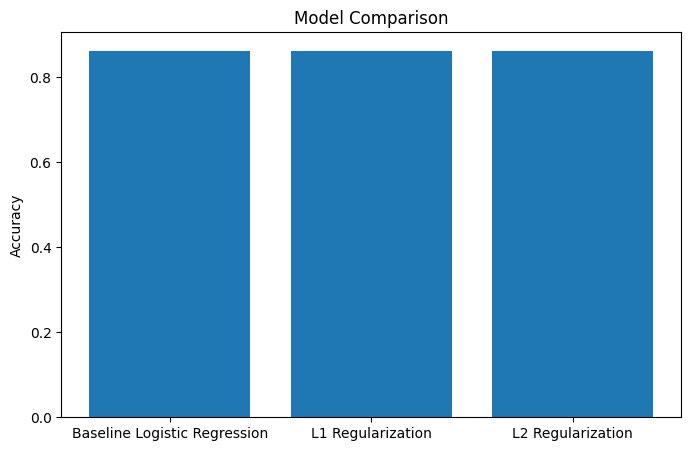

In [22]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

# Final Conclusion

Conclusion:

The Logistic Regression models were trained to predict employee turnover.

Among all models, the L2 Regularized Logistic Regression performed best because it reduced overfitting and achieved better prediction accuracy.